   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos de housing
housing = fetch_california_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)


In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)


In [ ]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
data_umap = reducer.fit_transform(data_scaled)


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(data_umap)


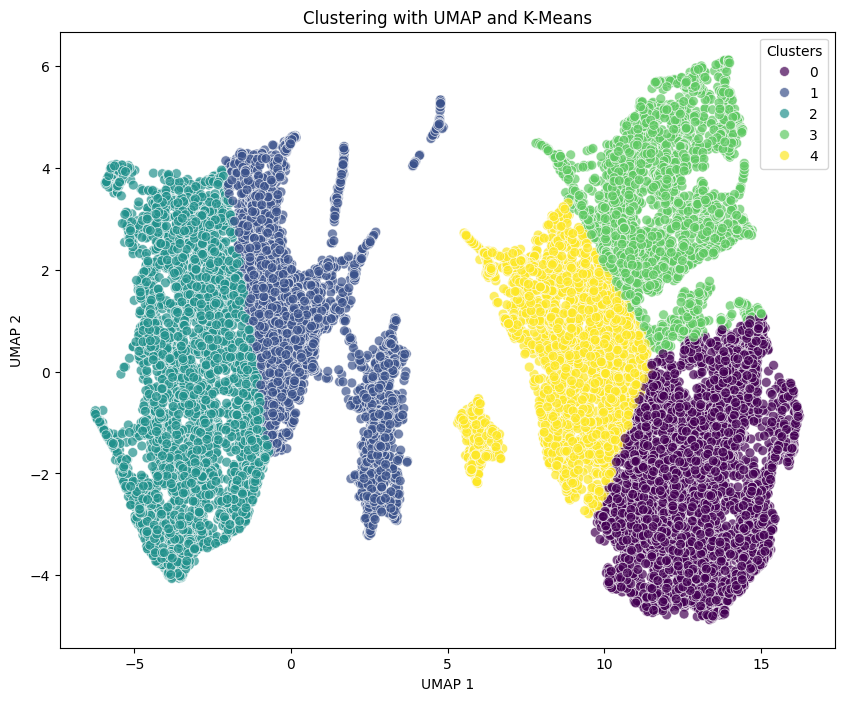

In [ ]:
plt.figure(figsize=(10, 8))
plt.title("Clustering with UMAP and K-Means")

sns.scatterplot(x=data_umap[:, 0], y=data_umap[:, 1], hue=kmeans_labels, palette="viridis", s=50, alpha=0.7)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title="Clusters", loc="best")
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.

/usr/local/lib/python3.10/dist-packages/umap/spectral.py:548: UserWarning:

Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!

/usr/local/lib/python3.10/dist-packages/umap/spectral.py:548: UserWarning:

Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!

/usr/local/lib/python3.10/dist-packages/umap/spectral.py:548: UserWarning:

Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation

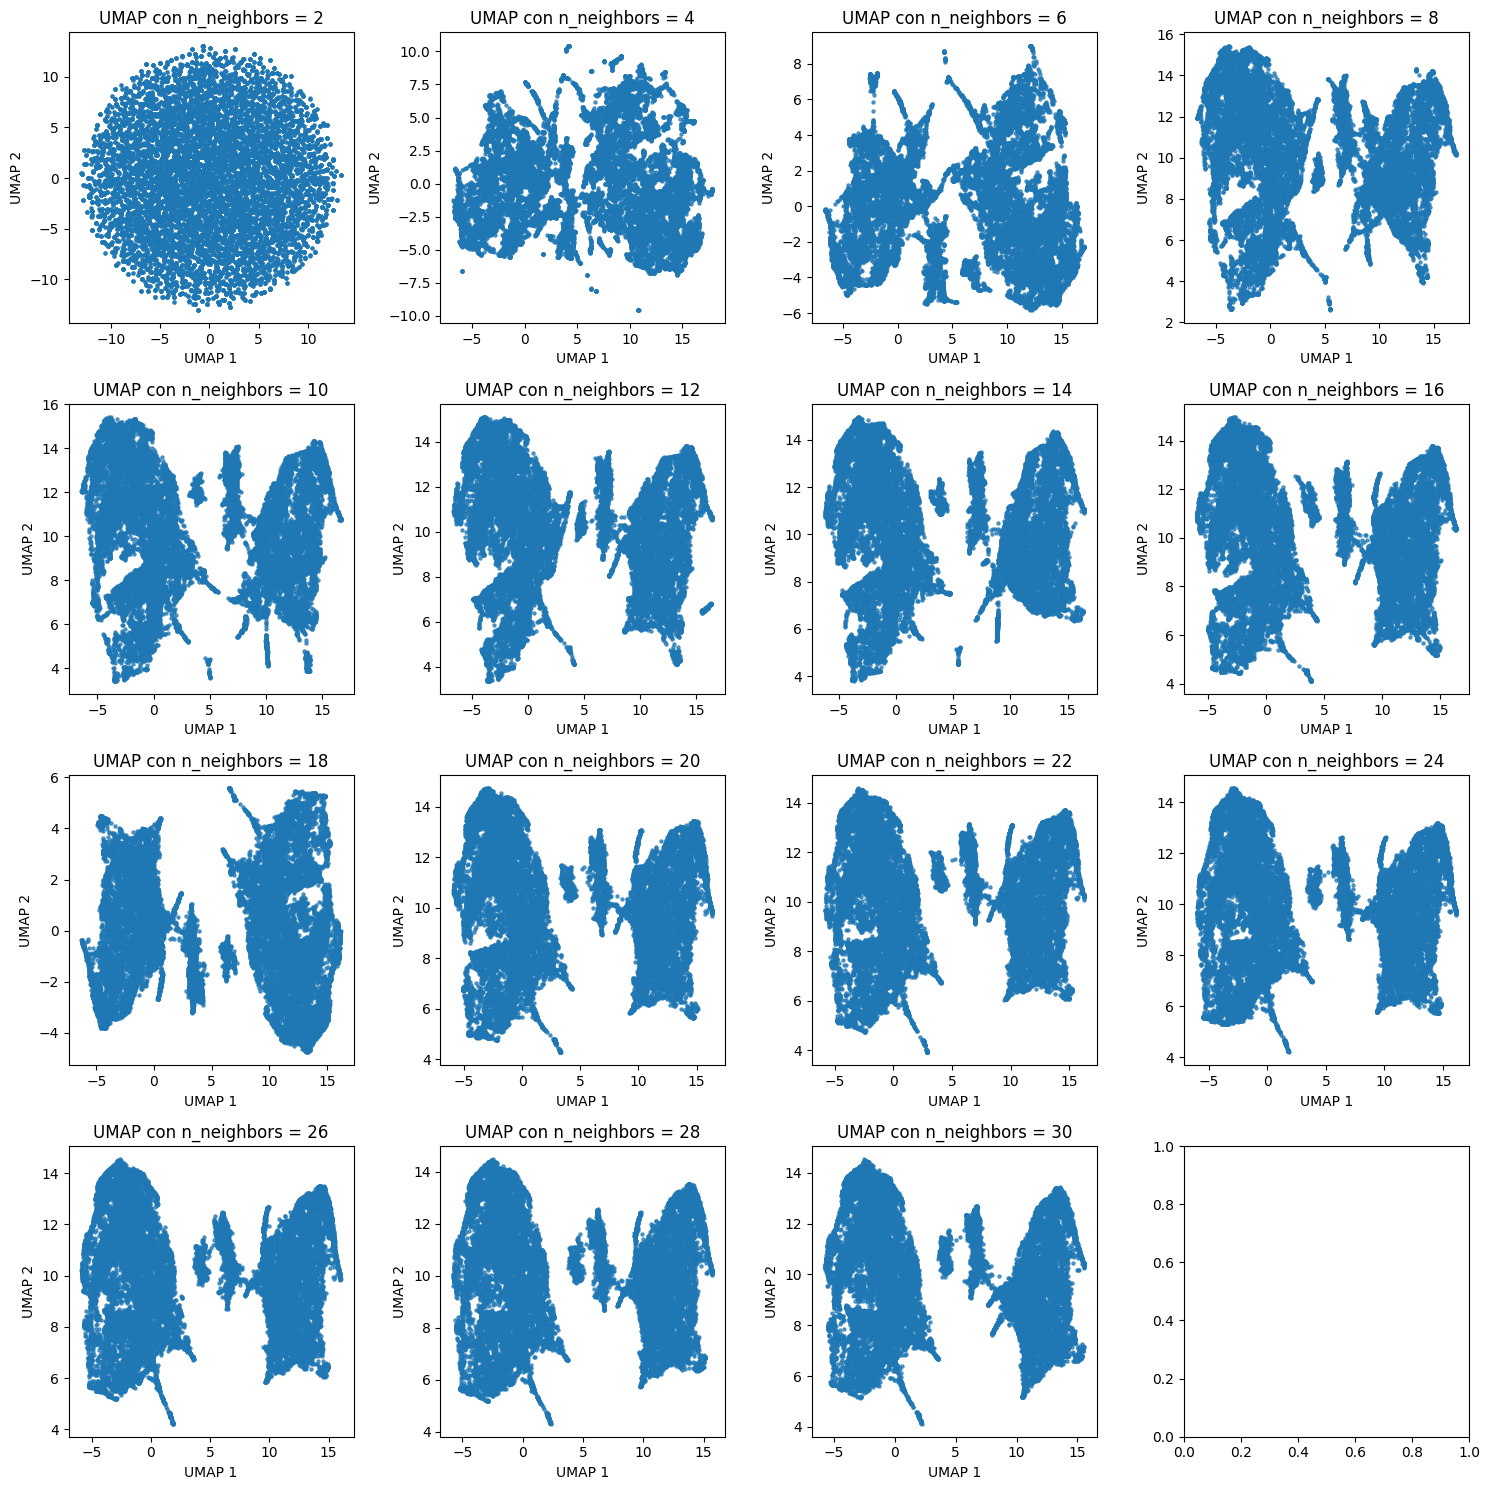

In [ ]:
# Definir los valores de n_neighbors para probar
n_neighbors_values = [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30]

# Calculate the number of rows and columns for the subplots
num_plots = len(n_neighbors_values)
num_cols = int(np.ceil(np.sqrt(num_plots)))  # Number of columns
num_rows = int(np.ceil(num_plots / num_cols))  # Number of rows

# Crear la figura y los subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 15)) # Adjusted figsize
axs = axs.ravel()  # Para iterar fácilmente en un bucle


# Generar un gráfico de UMAP para cada valor de n_neighbors
for i, n_neighbors in enumerate(n_neighbors_values):
    # Configurar UMAP y transformar los datos
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, n_components=2)
    data_umap = reducer.fit_transform(data_scaled)

    # Graficar
    axs[i].scatter(data_umap[:, 0], data_umap[:, 1], s=5, alpha=0.7)
    axs[i].set_title(f"UMAP con n_neighbors = {n_neighbors}")
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')

# Ajustar la disposición
plt.tight_layout()
plt.show()
